In [1]:
import sys
import os
import pandas as pd
import importlib

# Proje kök dizinini Python arama yolunda en üste al
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Proje kök dizinini arama yolunun en üstüne ekleyelim

# utils.py içindeki fonksiyonları import edelim
import src.utils as utils
importlib.reload(utils) # utils modülünü yeniden yükleyelim, böylece yapılan değişiklikler geçerli olur
chronogical_split = utils.chronogical_split

# EDA aşamasındaki veriyi yükleyelim
data_path = '../data/processed/nrel_data_5cities_filtered.parquet'
print(f"Veri dosyası: {data_path}...")
df = pd.read_parquet(data_path)
print(f"Veri başarıyla yüklendi. Toplam kayıt sayısı: {len(df)}")

# Kronolojik olarak veriyi bölerek eğitim ve test setlerini oluşturalım
train_df, val_df, test_df = chronogical_split(df, datetime_col ='datetime')

# 4. TEST VE SAĞLAMALAR (Hata yapıp yapmadığımızı buradan göreceğiz)
print("\n--- Veri Bölünme Raporu ---")
print(f"Eğitim Seti (Train) : {len(train_df):,} satır | Başlangıç: {train_df.index.min()} | Bitiş: {train_df.index.max()}")
print(f"Doğrulama Seti (Val): {len(val_df):,} satır  | Başlangıç: {val_df.index.min()} | Bitiş: {val_df.index.max()}")
print(f"Test Seti (Test)    : {len(test_df):,} satır  | Başlangıç: {test_df.index.min()} | Bitiş: {test_df.index.max()}")

# Şehir bazında dağılım kontrolü
print("\n--- Eğitim Setindeki Şehir Dağılımı ---")
print(train_df['City'].value_counts())

Veri dosyası: ../data/processed/nrel_data_5cities_filtered.parquet...
Veri başarıyla yüklendi. Toplam kayıt sayısı: 438000

--- Veri Bölünme Raporu ---
Eğitim Seti (Train) : 262,800 satır | Başlangıç: 0 | Bitiş: 262799
Doğrulama Seti (Val): 87,600 satır  | Başlangıç: 0 | Bitiş: 87599
Test Seti (Test)    : 87,600 satır  | Başlangıç: 0 | Bitiş: 87599

--- Eğitim Setindeki Şehir Dağılımı ---
City
Denver_CO     52560
Miami_FL      52560
Boston_MA     52560
Phoenix_AZ    52560
Seattle_WA    52560
Name: count, dtype: int64


In [2]:
import src.utils as utils
importlib.reload(utils) # utils.py içindeki yeni fonksiyonu algılasın

# Modelin kullanacağı özellikleri ve hedefi belirleyelim
TARGET_COL = 'GHI_Filtered' # Hedef değişkenimiz GHI_Filtered olacak
FEATURE_COLS = [
    'GHI_Filtered', 'Solar Zenith Angle', 'Temperature', 
    'Relative Humidity', 'Wind Speed', 'Cloud Type', 
    'Clearness_Index', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# 96 adım geçmişine bak (48 saat), 24 adım geleceği tahmin et (12 saat)
LOOK_BACK = 96
LOOK_FORWARD = 24

print("1. Eğitim (Train) seti hazırlanıyor...")
X_train, y_train = utils.create_sliding_features(train_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Train seti hazırlandı. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print("\n2. Doğrulama (Validation) seti hazırlanıyor...")
X_val, y_val = utils.create_sliding_features(val_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Validation seti hazırlandı. X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print("\n3. Test seti hazırlanıyor...")
X_test, y_test = utils.create_sliding_features(test_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Test seti hazırlandı. X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

1. Eğitim (Train) seti hazırlanıyor...
Train seti hazırlandı. X_train shape: (262205, 96, 11), y_train shape: (262205, 24)

2. Doğrulama (Validation) seti hazırlanıyor...
Validation seti hazırlandı. X_val shape: (87005, 96, 11), y_val shape: (87005, 24)

3. Test seti hazırlanıyor...
Test seti hazırlandı. X_test shape: (87005, 96, 11), y_test shape: (87005, 24)


In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader

print("\n--- Numpy Dizisinden Tensörler oluşturuluyor ---")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Batch size yani tanımlayalım
BATCH_SIZE = 128

print("\n--- DataLoader'lar oluşturuluyor ---")
# Eğitim seti için Shuffle = True yaparak veriyi karıştıralım ki ezberlemeyi önleyelim
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Doğrulama ve test setleri için Shuffle = False yaparak sıralı kalmasını sağlayalım
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader: {len(train_loader)} batch")
print(f"Validation DataLoader: {len(val_loader)} batch")
print(f"Test DataLoader: {len(test_loader)} batch")


--- Numpy Dizisinden Tensörler oluşturuluyor ---

--- DataLoader'lar oluşturuluyor ---
Train DataLoader: 2049 batch
Validation DataLoader: 680 batch
Test DataLoader: 680 batch


# AutoFormer Grafikleri

Model eğitimi için cihaz: MPS
1. Model Yükleniyor...
1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...
2. Metrikler Hesaplanıyor...

 TEST SETİ KARNESİ (2024)
---------------------------------
RMSE  : 96.82 
MAE   : 56.02 
nRMSE : 25.51%
nMAE  : 14.76%
MAPE  : 63.96% 
Accuracy  : 94.33%
Recall    : 95.30%
Precision : 88.38%
F1-Score  : 91.71%
ROC-AUC   : 98.36%
                  precision    recall  f1-score   support

 GHI≤200 (Düşük)       0.98      0.94      0.96   1400628
GHI>200 (Yüksek)       0.88      0.95      0.92    687492

        accuracy                           0.94   2088120
       macro avg       0.93      0.95      0.94   2088120
    weighted avg       0.95      0.94      0.94   2088120


3. Örnek Bir Zaman Dilimi Çizdiriliyor...


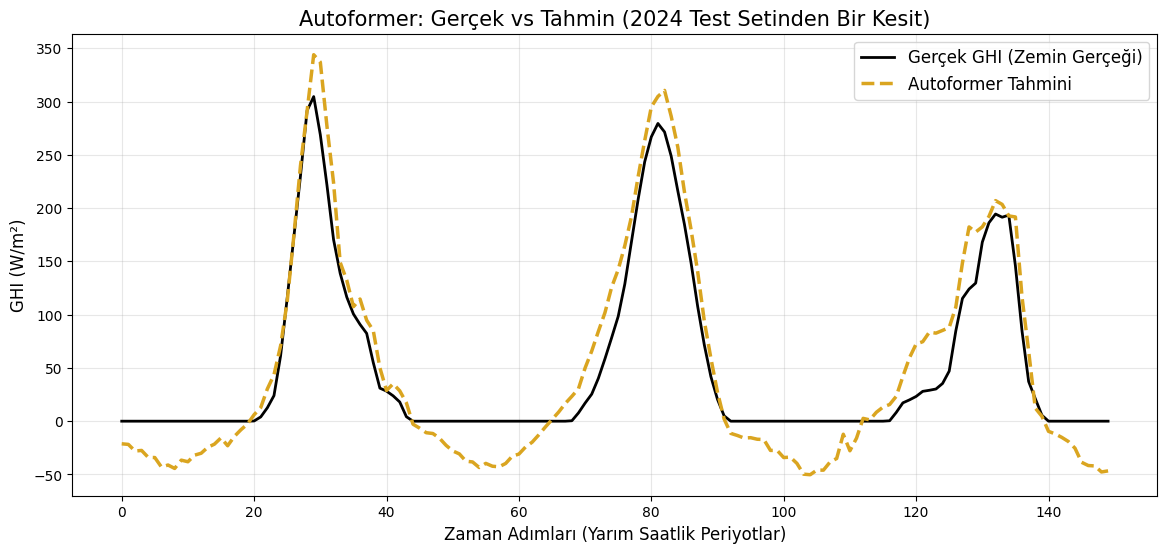

In [4]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import src.models.autoformer as autoformer_module
importlib.reload(autoformer_module) # Dosyayı RAM'den silip baştan okur!
from src.models.autoformer import CustomAutoFormer
import pandas as pd
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc, classification_report

# Cihaz Seçimi (GPU varsa kullan, yoksa CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Model eğitimi için cihaz: {device.type.upper()}")

print("1. Model Yükleniyor...")
# Boş modeli oluştur
model_autoformer = CustomAutoFormer(seq_len=96, pred_len=24, enc_in=11).to(device)
# State dictionary'yi yükle
model_autoformer.load_state_dict(torch.load('../outputs/models/autoformer_solar_model.pth'))

print("1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...")
model_autoformer.eval() # Modeli sınav moduna al (dropout vs kapatılır)

all_predictions = []
all_trues = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Tahmin yap
        outputs = model_autoformer(batch_X)
        
        # CPU'ya çek ve numpy array'e çevir
        all_predictions.append(outputs.cpu().numpy())
        all_trues.append(batch_y.cpu().numpy())

# Bütün batch'leri tek bir uzun listeye birleştir
all_predictions = np.concatenate(all_predictions, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

print("2. Metrikler Hesaplanıyor...")

GHI_THRESHOLD = 200  # W/m²  → "Güneşli mi değil mi?"

# Her adım için (N×24 → N*24 tek boyut)
y_true_flat = all_trues.flatten()
y_pred_flat = all_predictions.flatten()


# Binary sınıf: GHI > 200 → Güneşli (1), değil → (0)
y_true_cls = (y_true_flat > GHI_THRESHOLD).astype(int)
y_pred_cls = (y_pred_flat > GHI_THRESHOLD).astype(int)
y_score    =  y_pred_flat  # ROC için ham GHI değeri skor olarak kullanılır

accuracy  = accuracy_score(y_true_cls, y_pred_cls) * 100
precision = precision_score(y_true_cls, y_pred_cls, zero_division=0) * 100
recall    = recall_score(y_true_cls, y_pred_cls, zero_division=0) * 100
f1        = f1_score(y_true_cls, y_pred_cls, zero_division=0) * 100

fpr, tpr, _ = roc_curve(y_true_cls, y_score)
roc_auc     = auc(fpr, tpr) * 100

# Sadece ilk tahmin adımını (t+1) değil, tüm 24 adımlık (12 saat) ufku değerlendiriyoruz
mse = mean_squared_error(all_trues, all_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_trues, all_predictions)

# Gece saatlerini dışarıda bırak (GHI ~ 0 olan satırlar MAPE'yi patlatır)
daytime_mask = all_trues > 10

mean_ghi_daytime = np.mean(all_trues[daytime_mask])

nrmse = (rmse / mean_ghi_daytime) * 100
nmae  = (mae  / mean_ghi_daytime) * 100
mape  = np.mean(
    np.abs((all_trues[daytime_mask] - all_predictions[daytime_mask])
           / all_trues[daytime_mask])
) * 100

print(f"\n TEST SETİ KARNESİ (2024)")
print(f"---------------------------------")
print(f"RMSE  : {rmse:.2f} ")
print(f"MAE   : {mae:.2f} ")
print(f"nRMSE : {nrmse:.2f}%")   
print(f"nMAE  : {nmae:.2f}%")
print(f"MAPE  : {mape:.2f}% ")
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"F1-Score  : {f1:.2f}%")
print(f"ROC-AUC   : {roc_auc:.2f}%")
print(classification_report(y_true_cls, y_pred_cls,
      target_names=['GHI≤200 (Düşük)', 'GHI>200 (Yüksek)'], zero_division=0))

# ==========================================
# 3. GÖRSELLEŞTİRME (Gerçek Hava vs Model)
# ==========================================
print("\n3. Örnek Bir Zaman Dilimi Çizdiriliyor...")

START_IDX = 1000
WINDOW_SIZE = 150

# Tahminlerin sadece ilk ufuk adımını (t+1) alarak sürekli bir çizgi oluşturalım
true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, 0]
pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, 0]

plt.figure(figsize=(14, 6))
plt.plot(true_line, label='Gerçek GHI (Zemin Gerçeği)', color='black', linewidth=2)
plt.plot(pred_line, label='Autoformer Tahmini', color='#DAA520', linewidth=2.5, linestyle='--')

plt.title('Autoformer: Gerçek vs Tahmin (2024 Test Setinden Bir Kesit)', fontsize=15)
plt.xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Çıktıyı kaydet
plt.savefig('../outputs/plots/autoformer_test_predictions.pdf', bbox_inches='tight')
plt.show()


⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...

30 Dakika (t+1) → RMSE: 36.45, MAE: 25.24, R²: 0.9831, Pearson R: 0.9915, nRMSE: 9.60%, nMAE: 6.65%, MAPE: 22.95%
3 Saat (t+6) → RMSE: 91.28, MAE: 56.78, R²: 0.8939, Pearson R: 0.9454, nRMSE: 24.05%, nMAE: 14.96%, MAPE: 69.35%
6 Saat (t+12) → RMSE: 104.80, MAE: 61.43, R²: 0.8601, Pearson R: 0.9276, nRMSE: 27.62%, nMAE: 16.19%, MAPE: 69.75%
12 Saat (t+24) → RMSE: 105.83, MAE: 60.54, R²: 0.8573, Pearson R: 0.9262, nRMSE: 27.89%, nMAE: 15.95%, MAPE: 67.50%


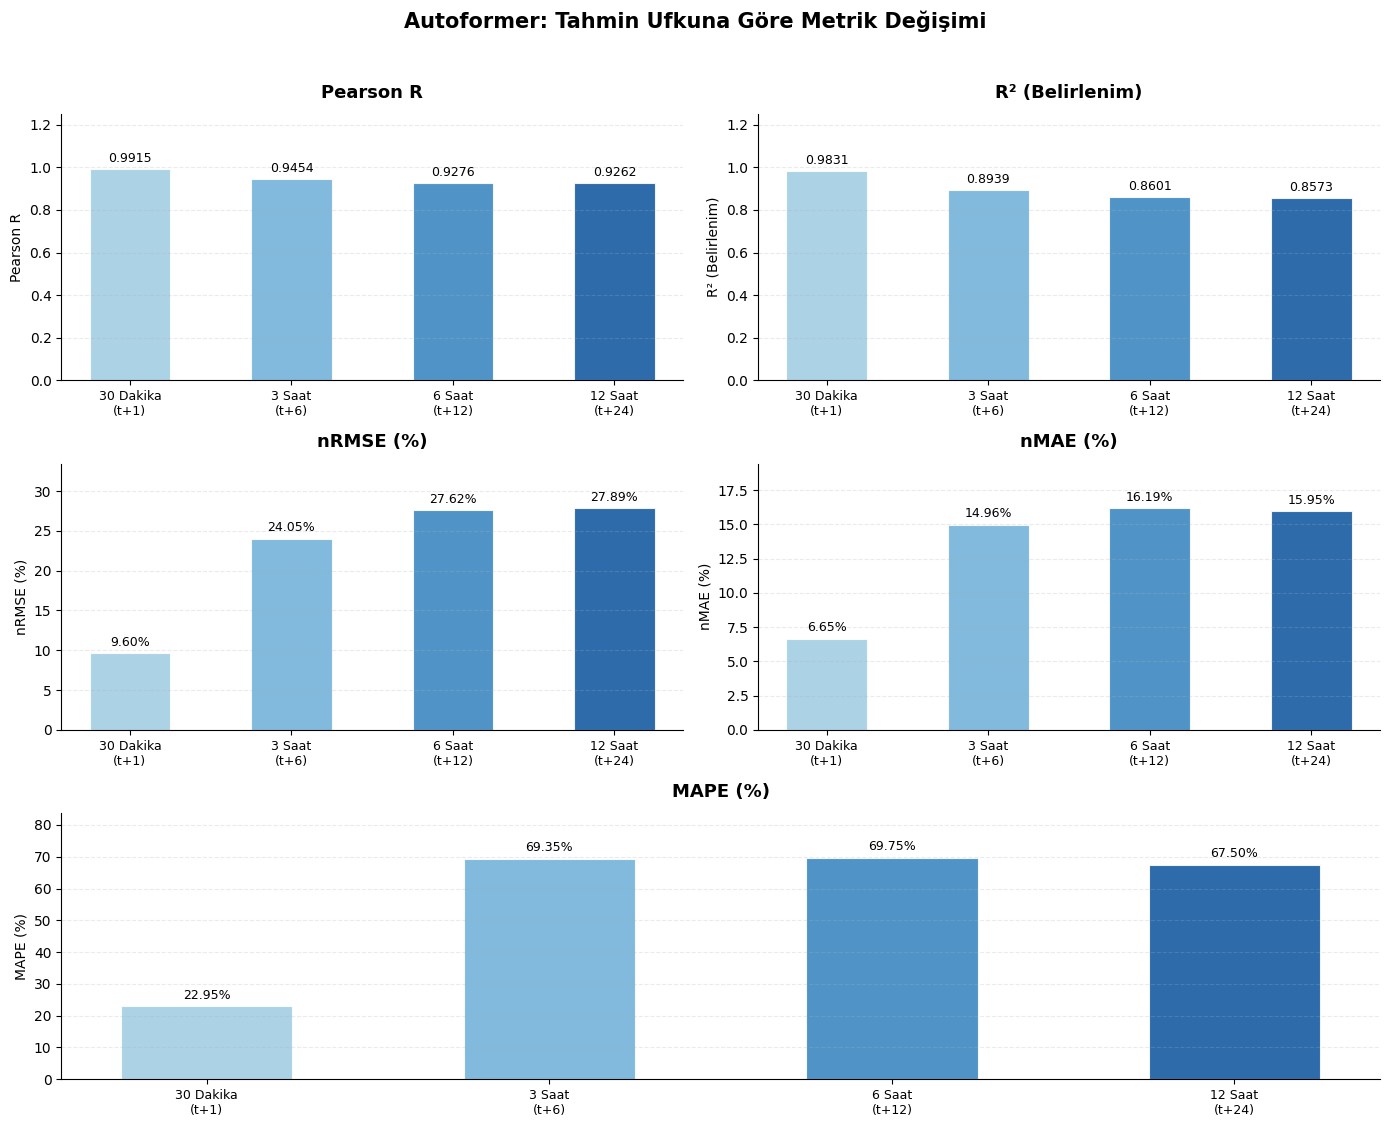

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

print("⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...\n")

horizons = [1, 6, 12, 24]
horizon_labels = ['30 Dakika\n(t+1)', '3 Saat\n(t+6)', '6 Saat\n(t+12)', '12 Saat\n(t+24)']

rmse_list, mae_list, mse_list, r2_list, r_list, nrmse_list, nmae_list, mape_list = [], [], [], [], [], [], [], []

for idx_h, h in enumerate(horizons):
    idx = h - 1
    true_h = all_trues[:, idx]
    pred_h = all_predictions[:, idx]

    rmse_val = np.sqrt(mean_squared_error(true_h, pred_h))
    mae_val = mean_absolute_error(true_h, pred_h)
    
    rmse_list.append(rmse_val)
    mae_list.append(mae_val)
    mse_list.append(mean_squared_error(true_h, pred_h))
    r2_list.append(r2_score(true_h, pred_h))
    r_list.append(pearsonr(true_h, pred_h)[0])
    
    mean_true = np.mean(true_h) if np.mean(true_h) != 0 else 1e-5

    # HATA DÜZELTME 2: Gündüz maskesini tüm array yerine sadece o ufuktaki (true_h) değerler için oluşturduk.
    daytime_mask = true_h > 10
    
    # Gündüz ortalaması 0 gelme ihtimaline karşı ufak bir güvenlik önlemi
    mean_ghi_daytime = np.mean(true_h[daytime_mask]) if np.sum(daytime_mask) > 0 else 1e-5

    nrmse = (rmse_val / mean_ghi_daytime) * 100
    nmae  = (mae_val  / mean_ghi_daytime) * 100
    
    if np.sum(daytime_mask) > 0:
        mape  = np.mean(np.abs((true_h[daytime_mask] - pred_h[daytime_mask]) / true_h[daytime_mask])) * 100
    else:
        mape = 0.0

    # HATA DÜZELTME 3: Hesaplanan metrikleri listelere ekledik!
    nrmse_list.append(nrmse)
    nmae_list.append(nmae)
    mape_list.append(mape)

    label = horizon_labels[idx_h].replace("\n", " ")
    print(f"{label} → RMSE: {rmse_list[-1]:.2f}, MAE: {mae_list[-1]:.2f}, R²: {r2_list[-1]:.4f}, Pearson R: {r_list[-1]:.4f}, nRMSE: {nrmse:.2f}%, nMAE: {nmae:.2f}%, MAPE: {mape:.2f}%")

# ==========================================
#  Grafik — 5 panel, 2 sütun (son satır ortada)
# ==========================================
autoformer_palette = ['#9ecae1', '#6baed6', '#3182bd', '#08519c'] 

metrics = [
    ('Pearson R',        r_list,    True),
    ('R² (Belirlenim)',  r2_list,   True),
    ('nRMSE (%)',        nrmse_list, False),
    ('nMAE (%)',         nmae_list,  False),
    ('MAPE (%)',         mape_list,  False)
]

fig = plt.figure(figsize=(14, 11)) 
fig.suptitle('Autoformer: Tahmin Ufkuna Göre Metrik Değişimi',
             fontsize=15, fontweight='bold', y=1.02)

x = np.arange(len(horizons))

for i, (name, values, bounded) in enumerate(metrics):
    if i < 4:
        ax = fig.add_subplot(3, 2, i + 1)
    else:
        ax = fig.add_subplot(3, 2, (5, 6))

    bars = ax.bar(x, values, color=autoformer_palette, alpha=0.85,
                  width=0.5, edgecolor='white', linewidth=0.8)

    ax.set_title(name, fontsize=13, fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(horizon_labels, fontsize=9)
    ax.set_ylabel(name, fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    max_val = max(values) if len(values) > 0 else 1
    if bounded:
        ax.set_ylim(0, 1.25) 
    else:
        ax.set_ylim(0, max_val * 1.2) 

    for bar, v in zip(bars, values):
        format_str = f'{v:.2f}%' if not bounded else f'{v:.4f}'
        
        ax.text(bar.get_x() + bar.get_width() / 2, 
                bar.get_height() + (max_val * 0.02), 
                format_str, 
                ha='center', va='bottom', fontsize=9, fontweight='500')

fig.tight_layout()
plt.savefig('../outputs/plots/autoformer_horizon_degradation.pdf', bbox_inches='tight', dpi=300)
plt.show()

📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...


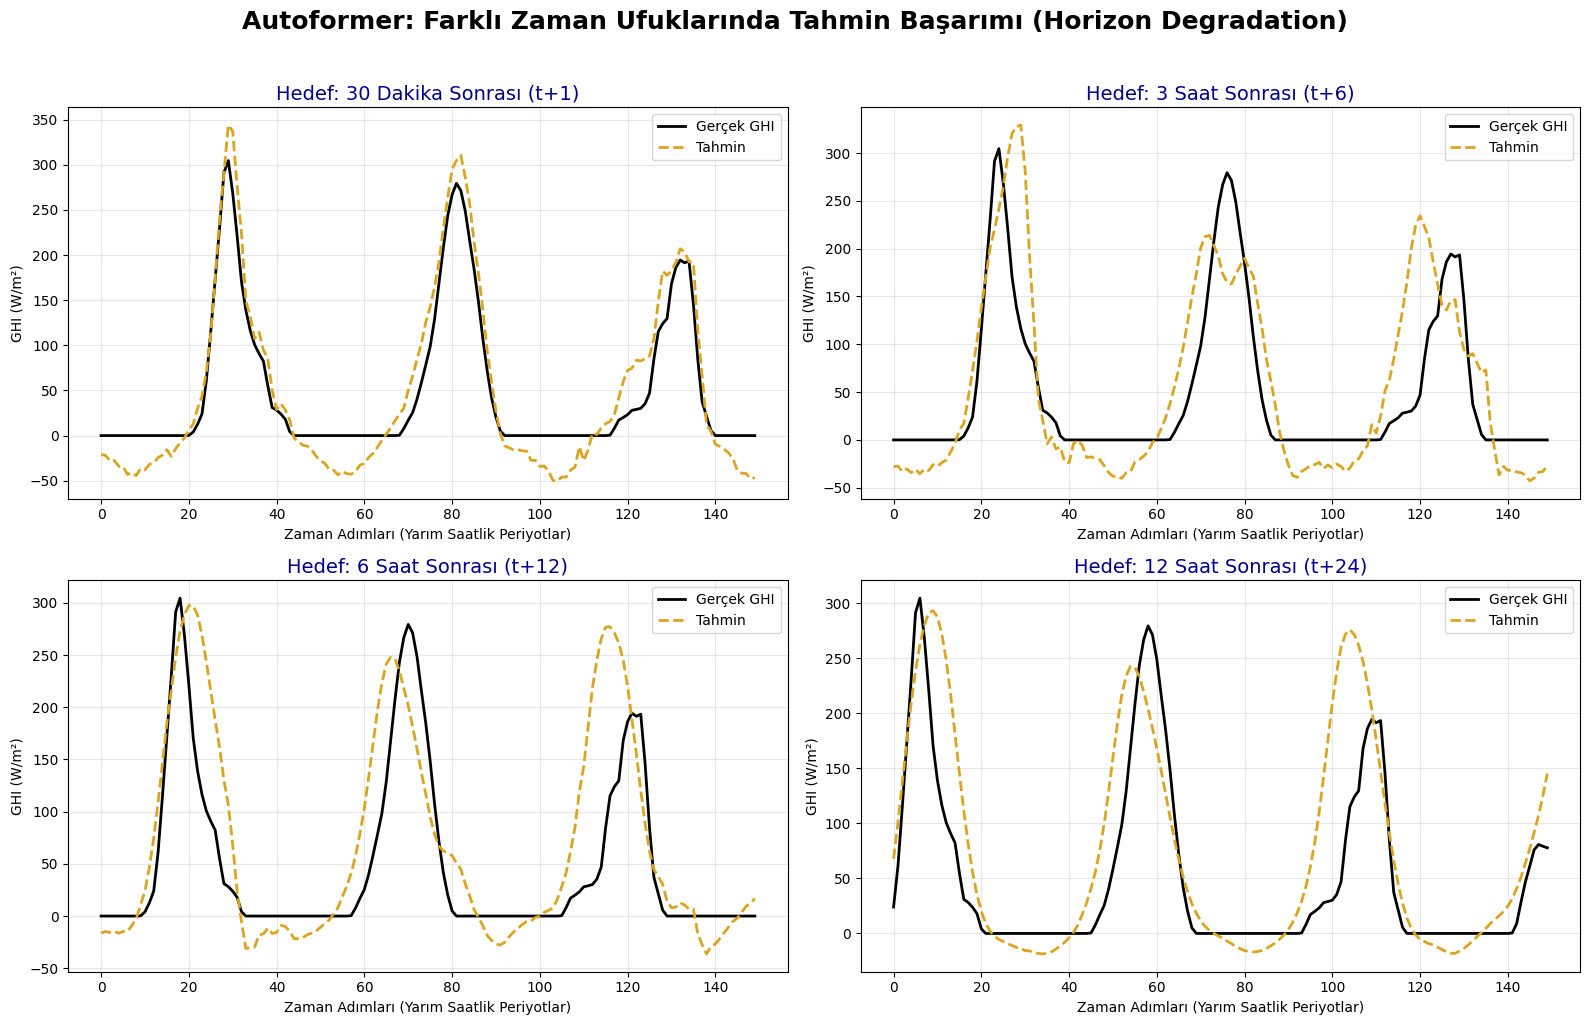

In [6]:
import matplotlib.pyplot as plt

print("📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...")

# İnceleyeceğimiz ufuklar ve indeksleri (Python'da indeks 0'dan başladığı için -1 yapıyoruz)
horizons_to_plot = [
    {"step": 1, "name": "30 Dakika Sonrası (t+1)", "idx": 0},
    {"step": 6, "name": "3 Saat Sonrası (t+6)", "idx": 5},
    {"step": 12, "name": "6 Saat Sonrası (t+12)", "idx": 11},
    {"step": 24, "name": "12 Saat Sonrası (t+24)", "idx": 23}
]

# Önceki grafikte kullandığımız aynı zaman aralığını alalım ki kıyaslama adil olsun
START_IDX = 1000
WINDOW_SIZE = 150

# 2x2'lik bir pano (subplot) oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Autoformer: Farklı Zaman Ufuklarında Tahmin Başarımı (Horizon Degradation)', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten() # 2x2'lik matrisi düz bir listeye çevir (Döngüde kolaylık için)

for i, h_info in enumerate(horizons_to_plot):
    ax = axes[i]
    idx = h_info["idx"]
    
    # Sadece o ufka (örneğin 3 saat sonrasına) ait tahminleri ve gerçekleri çek
    true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, idx]
    pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, idx]
    
    ax.plot(true_line, label='Gerçek GHI', color='black', linewidth=2)
    ax.plot(pred_line, label='Tahmin', color='#DAA520', linewidth=2, linestyle='--')
    
    ax.set_title(f"Hedef: {h_info['name']}", fontsize=14, color='darkblue')
    ax.set_xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=10)
    ax.set_ylabel('GHI (W/m²)', fontsize=10)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/autoformer_horizon_subplots.pdf', bbox_inches='tight')
plt.show()

🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...



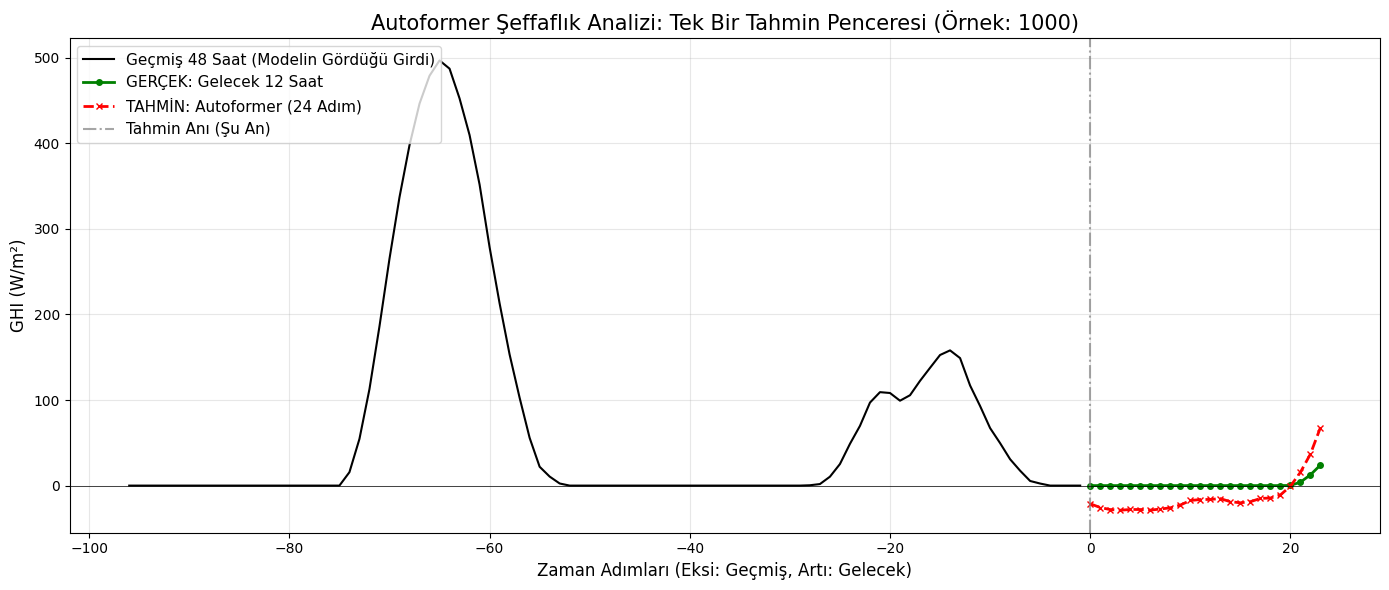

In [7]:
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...\n")

# Rastgele ama manidar bir zaman noktası seçelim (Örneğin test setinin 1000. adımı)
# İstersen bu rakamı 2000, 5000 yapıp farklı günlere de bakabilirsin.
SAMPLE_IDX = 1000

# 1. GEÇMİŞ: Modelin baktığı 96 adımlık geçmişi (X_test'ten) alıyoruz
# X_test boyutu (Örnek Sayısı, 96, 11). GHI_Filtered 0. indekste.
past_ghi = X_test[SAMPLE_IDX, :, 0] 

# 2. GELECEK: 24 adımlık gerçek değer ve modelin tahmini (all_trues ve all_predictions'dan)
true_future = all_trues[SAMPLE_IDX, :]
pred_future = all_predictions[SAMPLE_IDX, :]

# X ekseni (Zaman) ayarları: Geçmişi eksi (-), geleceği artı (+) olarak ayarlayalım
past_time = np.arange(-96, 0)
future_time = np.arange(0, 24)

# ==========================================
# 📊 GRAFİK ÇİZİMİ
# ==========================================
plt.figure(figsize=(14, 6))

# Geçmişi çiz
plt.plot(past_time, past_ghi, label='Geçmiş 48 Saat (Modelin Gördüğü Girdi)', color='black', linewidth=1.5)

# Geleceği çiz (Gerçek vs Tahmin)
plt.plot(future_time, true_future, label='GERÇEK: Gelecek 12 Saat', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(future_time, pred_future, label='TAHMİN: Autoformer (24 Adım)', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)

# Bugünü (0 noktasını) belirten dikey çizgi
plt.axvline(x=0, color='gray', linestyle='-.', alpha=0.7, label='Tahmin Anı (Şu An)')

plt.title(f'Autoformer Şeffaflık Analizi: Tek Bir Tahmin Penceresi (Örnek: {SAMPLE_IDX})', fontsize=15)
plt.xlabel('Zaman Adımları (Eksi: Geçmiş, Artı: Gelecek)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)

# X ekseni metinlerini düzenleyelim
plt.axhline(0, color='black', linewidth=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/autoformer_single_window_forecast.pdf')
plt.show()

# PATCHTST Grafikleri

Model eğitimi için cihaz: MPS
1. Model Yükleniyor...
1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...
2. Metrikler Hesaplanıyor...

 TEST SETİ KARNESİ (2024)
---------------------------------
RMSE  : 88.47 
MAE   : 50.90 
nRMSE : 23.32%  
nMAE  : 13.41%
MAPE  : 54.37% 
Accuracy  : 94.93%
Recall    : 95.39%
Precision : 89.84%
F1-Score  : 92.53%
ROC-AUC   : 98.65%
                  precision    recall  f1-score   support

 GHI≤200 (Düşük)       0.98      0.95      0.96   1400628
GHI>200 (Yüksek)       0.90      0.95      0.93    687492

        accuracy                           0.95   2088120
       macro avg       0.94      0.95      0.94   2088120
    weighted avg       0.95      0.95      0.95   2088120


3. Örnek Bir Zaman Dilimi Çizdiriliyor...


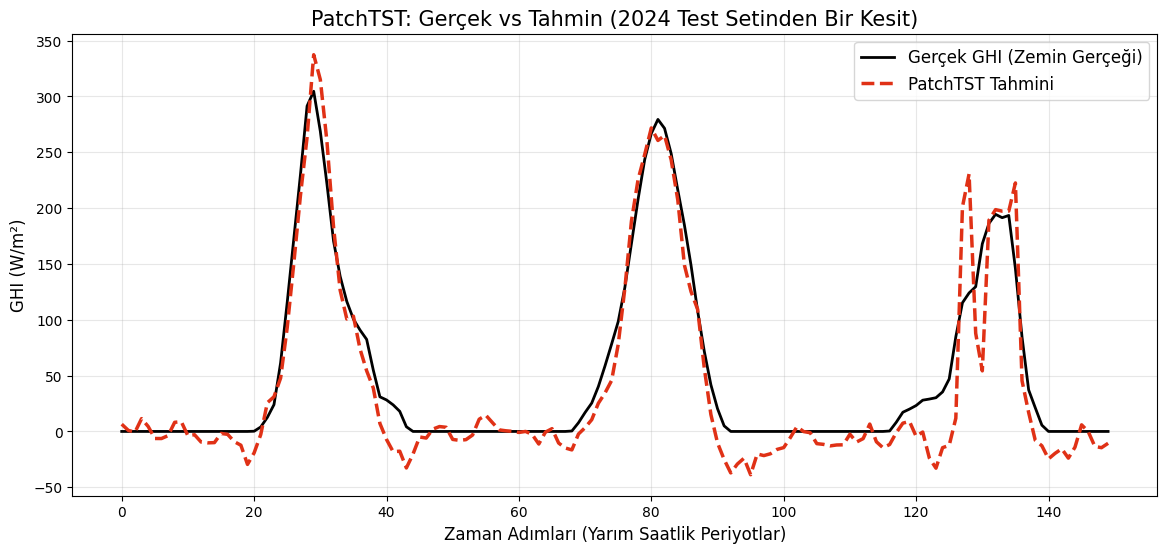

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Cihaz Seçimi (GPU varsa kullan, yoksa CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Model eğitimi için cihaz: {device.type.upper()}")

from src.models.patchtst import CustomPatchTST

print("1. Model Yükleniyor...")
# Boş modeli oluştur
model_patch = CustomPatchTST(seq_len=96, pred_len=24, enc_in=11).to(device)
# State dictionary'yi yükle
model_patch.load_state_dict(torch.load('../outputs/models/patchtst_solar_model.pth'))

print("1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...")
model_patch.eval() # Modeli sınav moduna al (dropout vs kapatılır)

all_predictions = []
all_trues = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Tahmin yap
        outputs = model_patch(batch_X)
        
        # CPU'ya çek ve numpy array'e çevir
        all_predictions.append(outputs.cpu().numpy())
        all_trues.append(batch_y.cpu().numpy())

# Bütün batch'leri tek bir uzun listeye birleştir
all_predictions = np.concatenate(all_predictions, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

print("2. Metrikler Hesaplanıyor...")

GHI_THRESHOLD = 200  # W/m²  → "Güneşli mi değil mi?"

# Her adım için (N×24 → N*24 tek boyut)
y_true_flat = all_trues.flatten()
y_pred_flat = all_predictions.flatten()

# Binary sınıf: GHI > 200 → Güneşli (1), değil → (0)
y_true_cls = (y_true_flat > GHI_THRESHOLD).astype(int)
y_pred_cls = (y_pred_flat > GHI_THRESHOLD).astype(int)
y_score    =  y_pred_flat  # ROC için ham GHI değeri skor olarak kullanılır

accuracy  = accuracy_score(y_true_cls, y_pred_cls) * 100
precision = precision_score(y_true_cls, y_pred_cls, zero_division=0) * 100
recall    = recall_score(y_true_cls, y_pred_cls, zero_division=0) * 100
f1        = f1_score(y_true_cls, y_pred_cls, zero_division=0) * 100

fpr, tpr, _ = roc_curve(y_true_cls, y_score)
roc_auc     = auc(fpr, tpr) * 100


# Sadece ilk tahmin adımını (t+1) değil, tüm 24 adımlık (12 saat) ufku değerlendiriyoruz
mse = mean_squared_error(all_trues, all_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_trues, all_predictions)

# Gece saatlerini dışarıda bırak (GHI ~ 0 olan satırlar MAPE'yi patlatır)
daytime_mask = all_trues > 10

mean_ghi_daytime = np.mean(all_trues[daytime_mask])

nrmse = (rmse / mean_ghi_daytime) * 100
nmae  = (mae  / mean_ghi_daytime) * 100
mape  = np.mean(
    np.abs((all_trues[daytime_mask] - all_predictions[daytime_mask])
           / all_trues[daytime_mask])
) * 100
print(f"\n TEST SETİ KARNESİ (2024)")
print(f"---------------------------------")
print(f"RMSE  : {rmse:.2f} ")
print(f"MAE   : {mae:.2f} ")
print(f"nRMSE : {nrmse:.2f}%  ")
print(f"nMAE  : {nmae:.2f}%")
print(f"MAPE  : {mape:.2f}% ")
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"F1-Score  : {f1:.2f}%")
print(f"ROC-AUC   : {roc_auc:.2f}%")
print(classification_report(y_true_cls, y_pred_cls,
      target_names=['GHI≤200 (Düşük)', 'GHI>200 (Yüksek)'], zero_division=0))
# ==========================================
# 3. GÖRSELLEŞTİRME (Gerçek Hava vs Model)
# ==========================================
print("\n3. Örnek Bir Zaman Dilimi Çizdiriliyor...")

START_IDX = 1000
WINDOW_SIZE = 150

# Tahminlerin sadece ilk ufuk adımını (t+1) alarak sürekli bir çizgi oluşturalım
true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, 0]
pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, 0]

plt.figure(figsize=(14, 6))
plt.plot(true_line, label='Gerçek GHI (Zemin Gerçeği)', color='black', linewidth=2)
plt.plot(pred_line, label='PatchTST Tahmini', color="#E03116", linewidth=2.5, linestyle='--')

plt.title('PatchTST: Gerçek vs Tahmin (2024 Test Setinden Bir Kesit)', fontsize=15)
plt.xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Çıktıyı kaydet
plt.savefig('../outputs/plots/patchtst_test_predictions.pdf', bbox_inches='tight')
plt.show()


⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...

30 Dakika (t+1) → RMSE: 36.18, MAE: 22.60, R²: 0.9833, Pearson R: 0.9919, nRMSE: 9.53%, nMAE: 5.95%, MAPE: 22.58%
3 Saat (t+6) → RMSE: 76.31, MAE: 44.14, R²: 0.9258, Pearson R: 0.9629, nRMSE: 20.11%, nMAE: 11.63%, MAPE: 46.71%
6 Saat (t+12) → RMSE: 93.17, MAE: 55.18, R²: 0.8894, Pearson R: 0.9450, nRMSE: 24.56%, nMAE: 14.54%, MAPE: 59.40%
12 Saat (t+24) → RMSE: 103.70, MAE: 61.08, R²: 0.8630, Pearson R: 0.9314, nRMSE: 27.32%, nMAE: 16.09%, MAPE: 65.50%


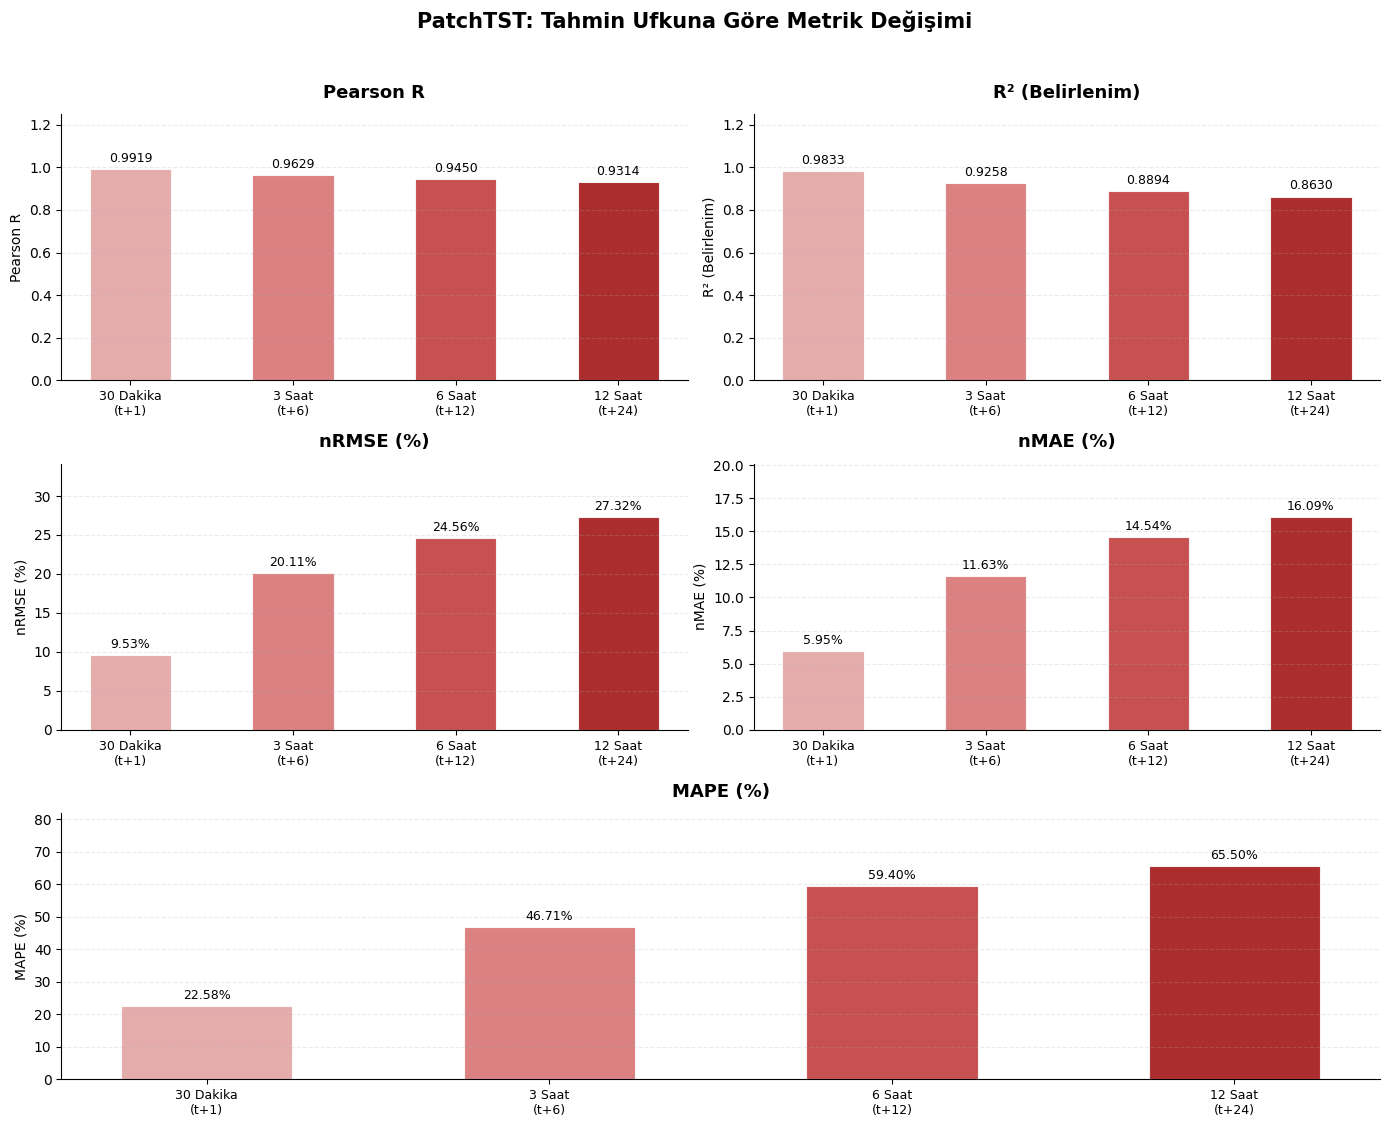

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

print("⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...\n")

horizons = [1, 6, 12, 24]
horizon_labels = ['30 Dakika\n(t+1)', '3 Saat\n(t+6)', '6 Saat\n(t+12)', '12 Saat\n(t+24)']

# HATA DÜZELTME: Eksik olan yüzde listeleri tanıma eklendi
rmse_list, mae_list, mse_list, r2_list, r_list = [], [], [], [], []
nrmse_list, nmae_list, mape_list = [], [], []

for idx_h, h in enumerate(horizons):
    idx = h - 1
    true_h = all_trues[:, idx]
    pred_h = all_predictions[:, idx]

    rmse = np.sqrt(mean_squared_error(true_h, pred_h))
    mae = mean_absolute_error(true_h, pred_h)
    mse = mean_squared_error(true_h, pred_h)
    r2 = r2_score(true_h, pred_h)
    r = pearsonr(true_h, pred_h)[0]

    rmse_list.append(rmse)
    mae_list.append(mae)
    mse_list.append(mse)
    r2_list.append(r2)
    r_list.append(r)

    # Gece saatlerini dışarıda bırak — bu horizon'a özel
    daytime_mask = true_h > 10
    mean_ghi_daytime = np.mean(true_h[daytime_mask])

    nrmse = (rmse / mean_ghi_daytime) * 100
    nmae  = (mae  / mean_ghi_daytime) * 100
    mape  = np.mean(
        np.abs((true_h[daytime_mask] - pred_h[daytime_mask]) / true_h[daytime_mask])
    ) * 100

    nrmse_list.append(nrmse)
    nmae_list.append(nmae)
    mape_list.append(mape)

    label = horizon_labels[idx_h].replace("\n", " ")
    print(f"{label} → RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}, Pearson R: {r:.4f}, nRMSE: {nrmse:.2f}%, nMAE: {nmae:.2f}%, MAPE: {mape:.2f}%")

# ==========================================
# 📊 GRAFİK — 5 panel, 2 sütun (son satır ortada)
# ==========================================
patchtst_palette = ["#e19e9e", "#d66b6b", "#bd3131", "#9c0808"]

metrics = [
    ('Pearson R',        r_list,    True),
    ('R² (Belirlenim)',  r2_list,   True),
    ('nRMSE (%)',        nrmse_list, False),
    ('nMAE (%)',         nmae_list,  False),
    ('MAPE (%)',         mape_list,  False)
]

fig = plt.figure(figsize=(14, 11))
fig.suptitle('PatchTST: Tahmin Ufkuna Göre Metrik Değişimi',
             fontsize=15, fontweight='bold', y=1.02)

x = np.arange(len(horizons))

for i, (name, values, bounded) in enumerate(metrics):
    if i < 4:
        ax = fig.add_subplot(3, 2, i + 1)
    else:
        ax = fig.add_subplot(3, 2, (5, 6))

    bars = ax.bar(x, values, color=patchtst_palette, alpha=0.85,
                  width=0.5, edgecolor='white', linewidth=0.8)

    ax.set_title(name, fontsize=13, fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(horizon_labels, fontsize=9)
    ax.set_ylabel(name, fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    # Grafik Y-Eksen sınırlarının dinamik ayarlanması
    max_val = max(values) if len(values) > 0 else 1
    if bounded:
        ax.set_ylim(0, 1.25)
    else:
        ax.set_ylim(0, max_val * 1.25) # Yazıların sığması için tavanı %25 esnettik

    # Değerleri barların üzerine yazdırma
    for bar, v in zip(bars, values):
        format_str = f'{v:.2f}%' if not bounded else f'{v:.4f}'
        
        # HATA DÜZELTME: Yazıların barların üzerinde düzgün hizalanması için dinamik ofset
        offset = 0.02 if bounded else (max_val * 0.02)
        
        ax.text(bar.get_x() + bar.get_width() / 2, 
                bar.get_height() + offset, 
                format_str, 
                ha='center', va='bottom', fontsize=9, fontweight='500')

fig.tight_layout()
plt.savefig('../outputs/plots/patchtst_horizon_degradation.pdf', bbox_inches='tight', dpi=300)
plt.show()

📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...


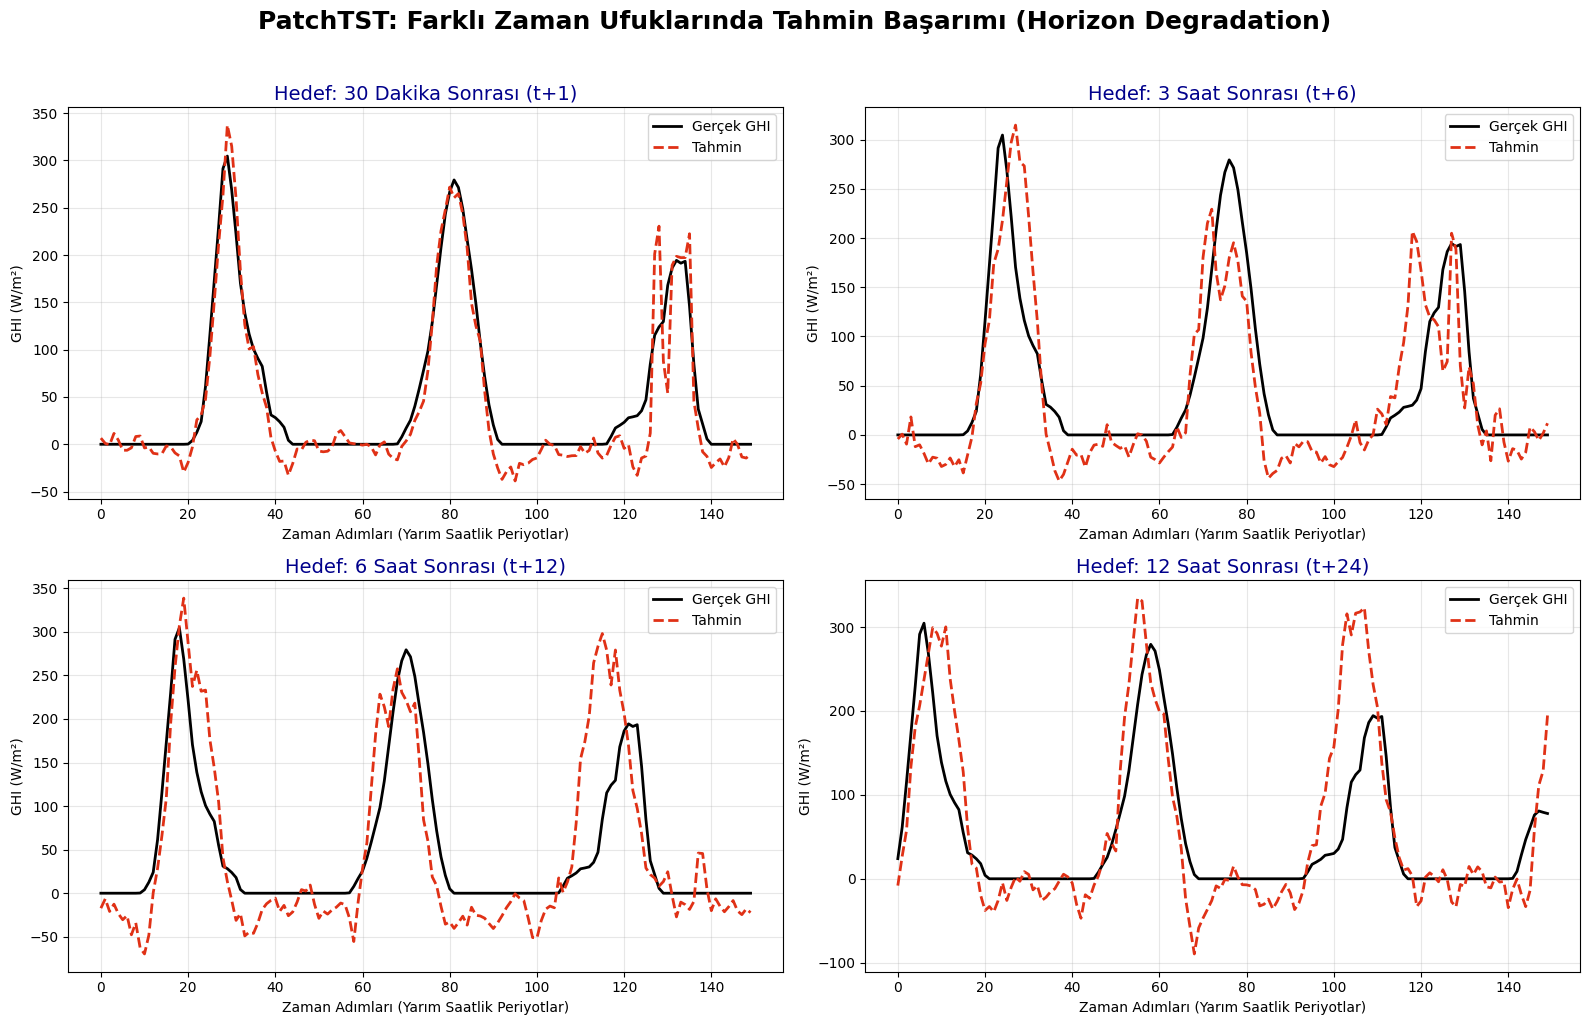

In [10]:
import matplotlib.pyplot as plt

print("📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...")

# İnceleyeceğimiz ufuklar ve indeksleri (Python'da indeks 0'dan başladığı için -1 yapıyoruz)
horizons_to_plot = [
    {"step": 1, "name": "30 Dakika Sonrası (t+1)", "idx": 0},
    {"step": 6, "name": "3 Saat Sonrası (t+6)", "idx": 5},
    {"step": 12, "name": "6 Saat Sonrası (t+12)", "idx": 11},
    {"step": 24, "name": "12 Saat Sonrası (t+24)", "idx": 23}
]

# Önceki grafikte kullandığımız aynı zaman aralığını alalım ki kıyaslama adil olsun
START_IDX = 1000
WINDOW_SIZE = 150

# 2x2'lik bir pano (subplot) oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PatchTST: Farklı Zaman Ufuklarında Tahmin Başarımı (Horizon Degradation)', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten() # 2x2'lik matrisi düz bir listeye çevir (Döngüde kolaylık için)

for i, h_info in enumerate(horizons_to_plot):
    ax = axes[i]
    idx = h_info["idx"]
    
    # Sadece o ufka (örneğin 3 saat sonrasına) ait tahminleri ve gerçekleri çek
    true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, idx]
    pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, idx]
    
    ax.plot(true_line, label='Gerçek GHI', color='black', linewidth=2)
    ax.plot(pred_line, label='Tahmin', color="#E03116", linewidth=2, linestyle='--')
    
    ax.set_title(f"Hedef: {h_info['name']}", fontsize=14, color='darkblue')
    ax.set_xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=10)
    ax.set_ylabel('GHI (W/m²)', fontsize=10)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/patchtst_horizon_subplots.pdf', bbox_inches='tight')
plt.show()

🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...



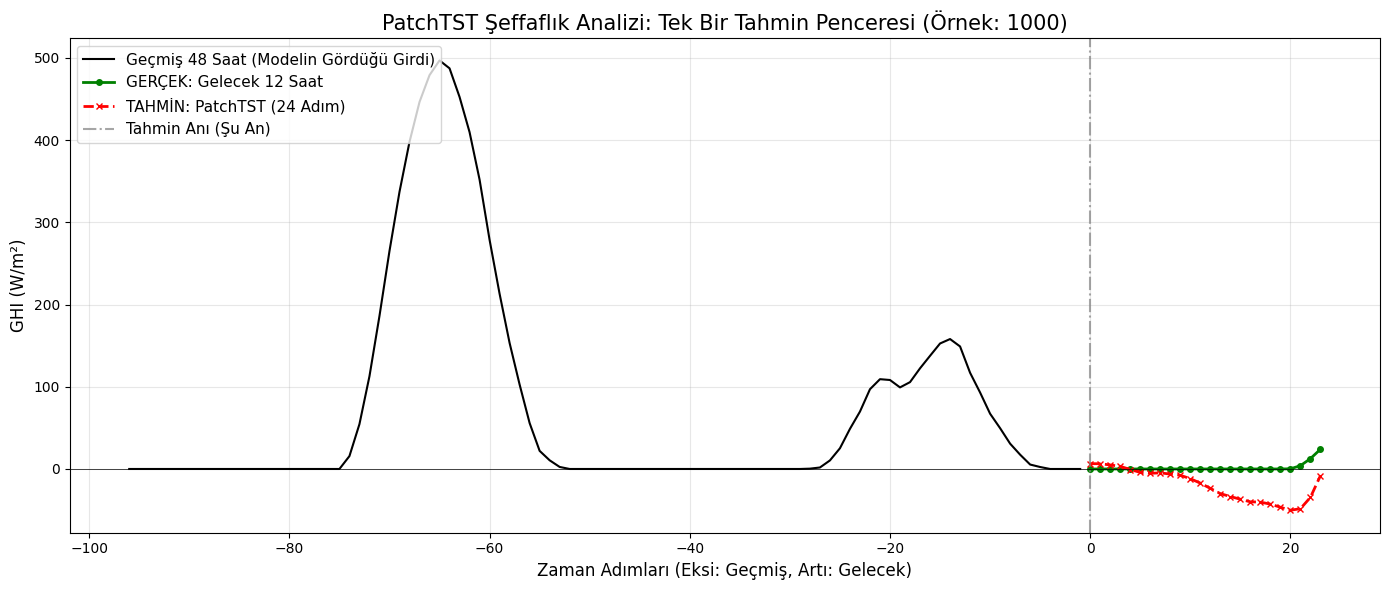

In [11]:
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...\n")

# Rastgele ama manidar bir zaman noktası seçelim (Örneğin test setinin 1000. adımı)
# İstersen bu rakamı 2000, 5000 yapıp farklı günlere de bakabilirsin.
SAMPLE_IDX = 1000

# 1. GEÇMİŞ: Modelin baktığı 96 adımlık geçmişi (X_test'ten) alıyoruz
# X_test boyutu (Örnek Sayısı, 96, 11). GHI_Filtered 0. indekste.
past_ghi = X_test[SAMPLE_IDX, :, 0] 

# 2. GELECEK: 24 adımlık gerçek değer ve modelin tahmini (all_trues ve all_predictions'dan)
true_future = all_trues[SAMPLE_IDX, :]
pred_future = all_predictions[SAMPLE_IDX, :]

# X ekseni (Zaman) ayarları: Geçmişi eksi (-), geleceği artı (+) olarak ayarlayalım
past_time = np.arange(-96, 0)
future_time = np.arange(0, 24)

# ==========================================
# 📊 GRAFİK ÇİZİMİ
# ==========================================
plt.figure(figsize=(14, 6))

# Geçmişi çiz
plt.plot(past_time, past_ghi, label='Geçmiş 48 Saat (Modelin Gördüğü Girdi)', color='black', linewidth=1.5)

# Geleceği çiz (Gerçek vs Tahmin)
plt.plot(future_time, true_future, label='GERÇEK: Gelecek 12 Saat', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(future_time, pred_future, label='TAHMİN: PatchTST (24 Adım)', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)

# Bugünü (0 noktasını) belirten dikey çizgi
plt.axvline(x=0, color='gray', linestyle='-.', alpha=0.7, label='Tahmin Anı (Şu An)')

plt.title(f'PatchTST Şeffaflık Analizi: Tek Bir Tahmin Penceresi (Örnek: {SAMPLE_IDX})', fontsize=15)
plt.xlabel('Zaman Adımları (Eksi: Geçmiş, Artı: Gelecek)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)

# X ekseni metinlerini düzenleyelim
plt.axhline(0, color='black', linewidth=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/patchtst_single_window_forecast.pdf')
plt.show()

Metrik     | Autoformer      | PatchTST       
---------------------------------------------
MSE        | 9373.8330       | 7827.7427      
RMSE       | 96.8186         | 88.4745        
MAE        | 56.0213         | 50.8975        
R2         | 0.8806          | 0.9003         
R          | 0.9384          | 0.9501         
nRMSE%     | 49.4869         | 45.2220        
nMAE%      | 28.6342         | 26.0152        
MAPE%      | 68910200.0000   | 78643875.0000  


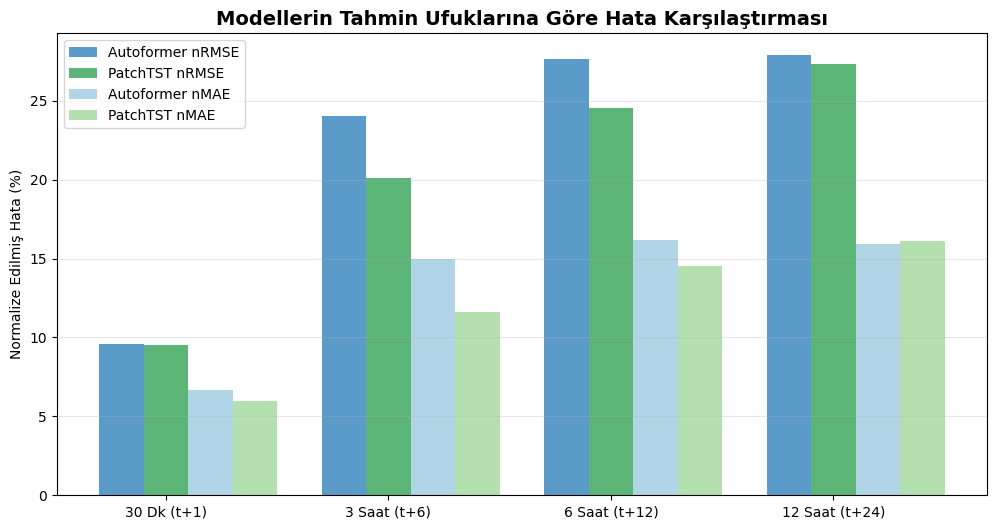

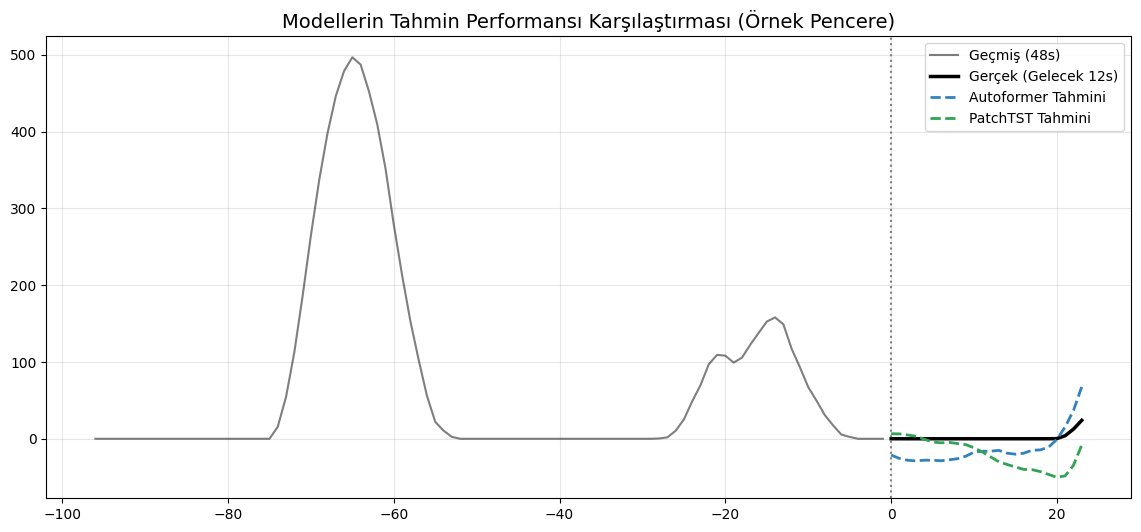

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Metrikleri Tek Bir Tabloda Özetleyelim
true_inputs = []
autoformer_preds = []
patchtst_preds = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Tahminleri al
        pred_auto = model_autoformer(batch_X)
        pred_patch = model_patch(batch_X)
        
        # CPU'ya çekip kaydedelim
        true_inputs.append(batch_y.cpu().numpy())
        autoformer_preds.append(pred_auto.cpu().numpy())
        patchtst_preds.append(pred_patch.cpu().numpy())

# Tüm batch'leri birleştiriyoruz (Şekil: Örnek Sayısı, 24)
all_trues = np.concatenate(true_inputs, axis=0)
all_preds_auto = np.concatenate(autoformer_preds, axis=0)
all_preds_patch = np.concatenate(patchtst_preds, axis=0)


def calculate_global_metrics(trues, preds):
    mse  = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(trues, preds)
    r2   = r2_score(trues, preds)
    r_coeff, _ = pearsonr(trues.flatten(), preds.flatten())

    mean_daytime = np.mean(trues)
    nrmse = (rmse / mean_daytime) * 100
    nmae  = (mae  / mean_daytime) * 100
    mape  = np.mean(np.abs((trues - preds) / (trues + 1e-5))) * 100

    return {"MSE": mse, "RMSE": rmse, "MAE": mae,
            "R2": r2, "R": r_coeff,
            "nRMSE%": nrmse, "nMAE%": nmae, "MAPE%": mape}

auto_metrics = calculate_global_metrics(all_trues, all_preds_auto)
patch_metrics = calculate_global_metrics(all_trues, all_preds_patch)


print(f"{'Metrik':<10} | {'Autoformer':<15} | {'PatchTST':<15}")
print("-" * 45)
for m in ["MSE", "RMSE", "MAE", "R2", "R", "nRMSE%", "nMAE%", "MAPE%"]:
    print(f"{m:<10} | {auto_metrics[m]:<15.4f} | {patch_metrics[m]:<15.4f}")

# 2. Grafik: İki Modelin Horizon Degradation Karşılaştırması
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.2
indices = np.arange(len(horizons))

horizons = [1, 6, 12, 24]
horizon_labels = ['30 Dk (t+1)', '3 Saat (t+6)', '6 Saat (t+12)', '12 Saat (t+24)']

auto_nrmse_h, auto_nmae_h = [], []
patch_nrmse_h, patch_nmae_h = [], []

for h in horizons:
    idx = h - 1
    # Autoformer adım metrikleri
    auto_nrmse_h.append(np.sqrt(mean_squared_error(all_trues[:, idx], all_preds_auto[:, idx])) / np.mean(all_trues[:, idx][all_trues[:, idx] > 10]) * 100)
    auto_nmae_h.append(mean_absolute_error(all_trues[:, idx], all_preds_auto[:, idx]) / np.mean(all_trues[:, idx][all_trues[:, idx] > 10]) * 100)
    # PatchTST adım metrikleri
    patch_nrmse_h.append(np.sqrt(mean_squared_error(all_trues[:, idx], all_preds_patch[:, idx])) / np.mean(all_trues[:, idx][all_trues[:, idx] > 10]) * 100)
    patch_nmae_h.append(mean_absolute_error(all_trues[:, idx], all_preds_patch[:, idx]) / np.mean(all_trues[:, idx][all_trues[:, idx] > 10]) * 100)

# Autoformer (Mavi tonları) ve PatchTST (Yeşil tonları)
ax.bar(indices - bar_width, auto_nrmse_h, width=bar_width, label='Autoformer nRMSE', color='#3182bd', alpha=0.8)
ax.bar(indices, patch_nrmse_h, width=bar_width, label='PatchTST nRMSE', color='#31a354', alpha=0.8)
ax.bar(indices + bar_width, auto_nmae_h, width=bar_width, label='Autoformer nMAE', color='#9ecae1', alpha=0.8)
ax.bar(indices + 2*bar_width, patch_nmae_h, width=bar_width, label='PatchTST nMAE', color='#a1d99b', alpha=0.8)

ax.set_title('Modellerin Tahmin Ufuklarına Göre Hata Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xticks(indices)
ax.set_xticklabels(horizon_labels)
ax.set_ylabel('Normalize Edilmiş Hata (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.savefig('../outputs/plots/comparison_metrics.pdf', bbox_inches='tight')
plt.show()

# 3. Grafik: PatchTST vs Autoformer Single Window (Örnekleme)
SAMPLE_IDX = 1000
plt.figure(figsize=(14, 6))
plt.plot(past_time, past_ghi, label='Geçmiş (48s)', color='black', alpha=0.5)
plt.plot(future_time, all_trues[SAMPLE_IDX, :], label='Gerçek (Gelecek 12s)', color='black', linewidth=2.5)
plt.plot(future_time, all_preds_auto[SAMPLE_IDX, :], label='Autoformer Tahmini', color='#3182bd', linestyle='--', linewidth=2)
plt.plot(future_time, all_preds_patch[SAMPLE_IDX, :], label='PatchTST Tahmini', color='#31a354', linestyle='--', linewidth=2)
plt.axvline(x=0, color='gray', linestyle=':')
plt.title('Modellerin Tahmin Performansı Karşılaştırması (Örnek Pencere)', fontsize=14)
plt.legend()
plt.savefig('../outputs/plots/comparison_single_window.pdf', bbox_inches='tight')
plt.grid(alpha=0.3)
plt.show()

In [13]:
import pandas as pd
import numpy as np

# all_trues gündüz değerleri
daytime_vals = all_trues.flatten()

print(f"Ortalama  : {daytime_vals.mean():.1f} W/m²")
print(f"Medyan    : {np.median(daytime_vals):.1f} W/m²")
print(f"25. Yüzde : {np.percentile(daytime_vals, 25):.1f} W/m²")
print(f"75. Yüzde : {np.percentile(daytime_vals, 75):.1f} W/m²")

# Her eşik için sınıf dağılımına bak
for t in [100, 150, 200, 250, 300, 350]:
    pos = (daytime_vals > t).sum()
    neg = (daytime_vals <= t).sum()
    ratio = pos / len(daytime_vals) * 100
    print(f"Eşik {t:4d}: Yüksek={pos:6d} (%{ratio:.1f})  Düşük={neg:6d} (%{100-ratio:.1f})")

Ortalama  : 195.6 W/m²
Medyan    : 16.6 W/m²
25. Yüzde : 0.0 W/m²
75. Yüzde : 345.7 W/m²
Eşik  100: Yüksek=831951 (%39.8)  Düşük=1256169 (%60.2)
Eşik  150: Yüksek=755029 (%36.2)  Düşük=1333091 (%63.8)
Eşik  200: Yüksek=687492 (%32.9)  Düşük=1400628 (%67.1)
Eşik  250: Yüksek=626409 (%30.0)  Düşük=1461711 (%70.0)
Eşik  300: Yüksek=568989 (%27.2)  Düşük=1519131 (%72.8)
Eşik  350: Yüksek=517009 (%24.8)  Düşük=1571111 (%75.2)


Horizon t+1: Accuracy=98.17%, F1-Score=97.25%, ROC-AUC=99.85%
Horizon t+1: Accuracy=98.01%, F1-Score=96.99%, ROC-AUC=99.80%
Horizon t+4: Accuracy=94.84%, F1-Score=92.44%, ROC-AUC=98.83%
Horizon t+4: Accuracy=96.16%, F1-Score=94.27%, ROC-AUC=99.29%
Horizon t+8: Accuracy=93.86%, F1-Score=91.11%, ROC-AUC=98.18%
Horizon t+8: Accuracy=94.88%, F1-Score=92.45%, ROC-AUC=98.76%
Horizon t+12: Accuracy=93.94%, F1-Score=91.18%, ROC-AUC=98.12%
Horizon t+12: Accuracy=94.46%, F1-Score=91.90%, ROC-AUC=98.48%
Horizon t+18: Accuracy=93.88%, F1-Score=91.05%, ROC-AUC=98.07%
Horizon t+18: Accuracy=94.21%, F1-Score=91.54%, ROC-AUC=98.31%
Horizon t+24: Accuracy=93.83%, F1-Score=90.98%, ROC-AUC=98.07%
Horizon t+24: Accuracy=94.07%, F1-Score=91.29%, ROC-AUC=98.19%


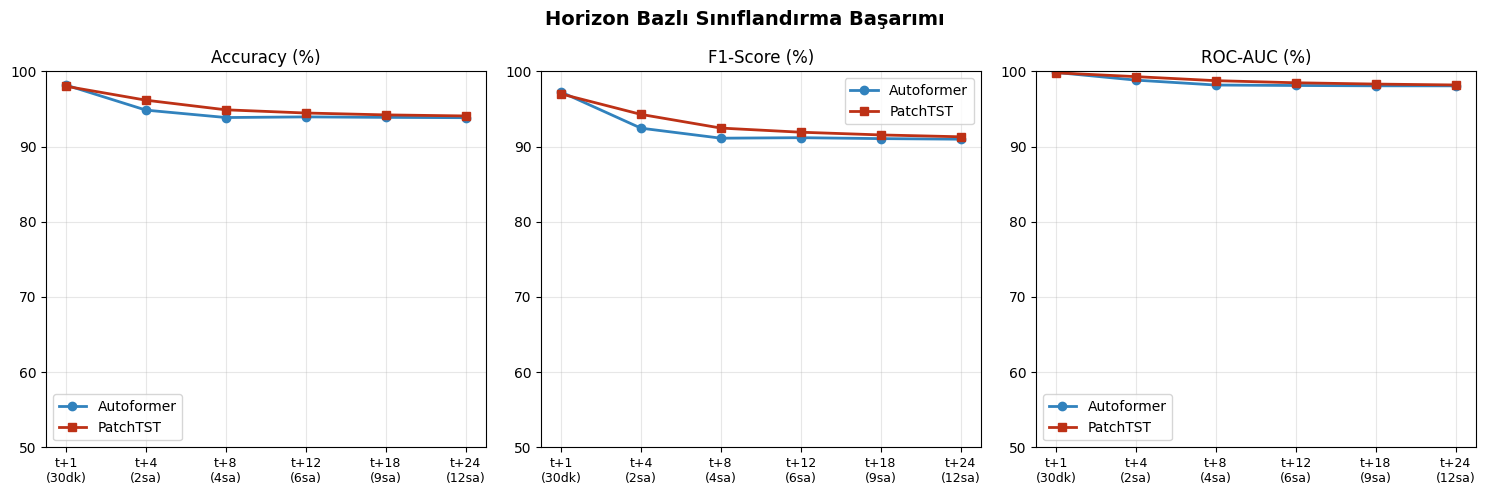

In [14]:
import matplotlib.pyplot as plt

horizons      = [1, 4, 8, 12, 18, 24]
horizon_names = ['t+1\n(30dk)', 't+4\n(2sa)', 't+8\n(4sa)',
                 't+12\n(6sa)', 't+18\n(9sa)', 't+24\n(12sa)']

auto_acc, patch_acc   = [], []
auto_f1,  patch_f1    = [], []
auto_auc, patch_auc   = [], []

for h in horizons:
    idx = h - 1
    for preds, acc_list, f1_list, auc_list in [
        (all_preds_auto,  auto_acc,  auto_f1,  auto_auc),
        (all_preds_patch, patch_acc, patch_f1, patch_auc),
    ]:
        t = all_trues[:, idx].flatten()
        p = preds[:, idx].flatten()

        y_t = (t > GHI_THRESHOLD).astype(int)
        y_p = (p > GHI_THRESHOLD).astype(int)

        acc_list.append(accuracy_score(y_t, y_p) * 100)
        f1_list.append(f1_score(y_t, y_p, zero_division=0) * 100)
        fpr, tpr, _ = roc_curve(y_t, p)
        auc_list.append(auc(fpr, tpr) * 100)

        print(f"Horizon t+{h}: Accuracy={acc_list[-1]:.2f}%, F1-Score={f1_list[-1]:.2f}%, ROC-AUC={auc_list[-1]:.2f}%")

x = range(len(horizons))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Horizon Bazlı Sınıflandırma Başarımı', fontsize=14, fontweight='bold')

for ax, auto_vals, patch_vals, title in zip(
    axes,
    [auto_acc,  auto_f1,  auto_auc],
    [patch_acc, patch_f1, patch_auc],
    ['Accuracy (%)', 'F1-Score (%)', 'ROC-AUC (%)']
):
    ax.plot(x, auto_vals,  marker='o', color='#3182bd', label='Autoformer', linewidth=2)
    ax.plot(x, patch_vals, marker='s', color='#bd3116', label='PatchTST',   linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(horizon_names, fontsize=9)
    ax.set_ylim(50, 100)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/horizon_classification_metrics.pdf', bbox_inches='tight')
plt.show()